# 3. Figures

Draw the figures from the tables the earlier notebooks wrote.  Figures go to
`figure/`.

| input | what it provides |
| --- | --- |
| `metadata/params.csv` | one row per spectrum: the table built in notebook 0; fixes the row order |
| `data/F30_norm.csv` | one column per spectrum: the continuum removed fluxes built in notebook 1 |
| `results/umap_*.csv` | one file per UMAP `n_neighbors` run, each `params.csv` with `umap_x`, `umap_y` and `DB_label` appended |

**Run order: 0 -> 1 -> 2 -> appendix1 -> 3.**  Notebook 2 writes only the
`n_neighbors = 12` run; the 16, 20 and 24 runs come from
`appendix1_hyperparameters.ipynb`.

The four runs are read into one table, each under its own suffix (`umap_x_12`,
`DB_label_12`, ...), and `hyper_parameter` picks the run to draw.  Every figure
after the embeddings reads the 12 run, whose cluster 0 holds both the
normal-velocity and the 91T-like supernovae; `cluster_groups()` splits it by
`SN_type` into `NV1` and `91T` once, and each figure draws from that.


## Imports

In [1]:
import copy
import os

import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

## Configuration


In [3]:
# Input / output locations
PARAMS_PATH = './metadata/params.csv'
SPECTRUM_TABLE_PATH = './data/F30_norm.csv'

FIGURE_DIR = './figure'
RESULTS_DIR = './results'

# The runs of notebook 2, by the UMAP `n_neighbors` each was made with.  The file
# name records the whole run: wavelength window, UMAP dimensions and neighbours,
# HDBSCAN epsilon.
RESULTS_PATHS = {
    12: f'{RESULTS_DIR}/umap_5100_6450_dim2_nei12_eps0475.csv',
    16: f'{RESULTS_DIR}/umap_5100_6450_dim2_nei16_eps0450.csv',
    20: f'{RESULTS_DIR}/umap_5100_6450_dim2_nei20_eps0380.csv',
    24: f'{RESULTS_DIR}/umap_5100_6450_dim2_nei24_eps0410.csv',
}

# Columns notebook 2 appends to params.csv.  Here each one takes the suffix of the
# run it came from, so that all four runs fit in one table.
EMBEDDING_COLUMNS = ['umap_x', 'umap_y']
LABEL_COLUMN = 'DB_label'

# Column label format written by notebook 1: '<SN name>%%%<SN type>$$$<phase>'
NAME_TYPE_SEPARATOR = '%%%'

# Wavelength window the mean spectra are drawn over [Angstrom].  It is the window
# notebook 2 handed to UMAP -- the Si II 5972 and 6355 features the clustering
# rests on -- so the figure shows the part of the spectrum the clusters came from.
WINDOW_MIN_AA = 5100
WINDOW_MAX_AA = 6450

In [4]:
# `ratio` is the projected distance of the supernova from the centre of its host,
# in units of the host radius.  The embeddings mark the supernovae inside this
# with a larger star, and the figures against `ratio` draw it as a line.
INNER_OUTER_RATIO = 0.7

# The Si II velocity that separates the high-velocity supernovae from the normal
# ones [10^4 km/s], drawn as a line in the velocity figures.
HV_VELOCITY = 1.2

# A supernova with no measured decline rate carries the placeholder 9.99, so the
# figures against Dm15 keep only the ones below this.
MAX_DECLINE_RATE = 3

## Plot style


In [5]:
FIGURE_SIZE = (5.0, 5.0)
SPECTRUM_FIGURE_SIZE = (10.0, 4.5)

plt.rcParams['figure.figsize'] = FIGURE_SIZE
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'Arial'

plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['xtick.bottom'] = 'True'
plt.rcParams['xtick.top'] = 'True'
plt.rcParams['ytick.left'] = 'True'
plt.rcParams['ytick.right'] = 'True'
plt.rcParams['xtick.minor.visible'] = 'True'
plt.rcParams['ytick.minor.visible'] = 'True'

plt.rcParams['xtick.major.width'] = 1
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['xtick.minor.width'] = 0.5
plt.rcParams['ytick.minor.width'] = 0.5
plt.rcParams['xtick.major.size'] = 7
plt.rcParams['ytick.major.size'] = 7
plt.rcParams['xtick.minor.size'] = 4
plt.rcParams['ytick.minor.size'] = 4

## Reading the inputs


In [6]:
def load_params(params_path=PARAMS_PATH):
    """Read the metadata table built in notebook 0.

    Its row order is the row order of every result file.
    """
    return pd.read_csv(params_path)

In [7]:
def load_results(params, results_paths=RESULTS_PATHS):
    """Add the embedding and the cluster label of every run of notebook 2 to `params`.

    Each result file is `params.csv` with `umap_x`, `umap_y` and `DB_label`
    appended, in the row order of `params.csv`; the three are carried over under
    the suffix of the run they came from, so that `umap_x_12` is the embedding of
    the `n_neighbors = 12` run and `DB_label_12` its cluster label.
    """
    data = params.copy()

    for hyper_parameter, path in results_paths.items():
        result = pd.read_csv(path)

        if not result['SN_name'].equals(params['SN_name']):
            raise ValueError(f'{path} does not follow the row order of params.csv')

        for column in EMBEDDING_COLUMNS + [LABEL_COLUMN]:
            data[f'{column}_{hyper_parameter}'] = result[column]

    return data

In [8]:
def load_fluxes(params, spectrum_path=SPECTRUM_TABLE_PATH,
                window_min=WINDOW_MIN_AA, window_max=WINDOW_MAX_AA):
    """Read the normalized spectrum table of notebook 1 as one row per supernova.

    The table holds one column per spectrum, labelled
    `<SN name>%%%<SN type>$$$<phase>`, and one row per wavelength bin.  It is cut
    to the window given, transposed so that each supernova becomes a row and each
    wavelength a column, and reordered to follow the rows of `params`, so that a
    selection of the metadata selects the same supernovae here.  The cut is the
    one notebook 2 made before embedding, so the mean spectra are drawn over the
    part of the spectrum the clusters came from.
    """
    spectra = pd.read_csv(spectrum_path).set_index('AA')
    spectra = spectra[(spectra.index > window_min) & (spectra.index < window_max)]

    column_of = {column.split(NAME_TYPE_SEPARATOR)[0]: column for column in spectra.columns}
    if len(column_of) != len(spectra.columns):
        raise ValueError('the spectrum table holds more than one spectrum per supernova')

    # A missing supernova raises a KeyError naming it
    ordered = spectra[[column_of[name] for name in params['SN_name']]]

    return ordered.T.reset_index(drop=True)

## Colours and labels


In [9]:
# Settings for each SN type, used by the embeddings coloured by subtype
umap_settings = {
    'NV': {'color': 'tab:blue', 'label': 'NV', 'shown': False},
    'HV': {'color': 'tab:green', 'label': 'HV', 'shown': False},
    '91T': {'color': 'tab:olive', 'label': '91T', 'shown': False},
    '91bg': {'color': 'tab:red', 'label': '91bg', 'shown': False},
    'Iax': {'color': 'tab:purple', 'label': 'Iax', 'shown': False},
    '00cx': {'color': 'tab:pink', 'label': '00cx', 'shown': False}
}

In [10]:
# Settings for each HDBSCAN label, one dictionary per run of notebook 2.  The key
# is the label the run assigned; the order of the entries is the order the legend
# is sorted into.  -1 is a spectrum HDBSCAN left unclustered.
db12_settings = {
    3: {'color': 'tab:blue', 'label': 'cluster 0 (NV1+91T)', 'shown': False},
    5: {'color': 'tab:orange', 'label': 'cluster 1 (NV2)', 'shown': False},
    1: {'color': 'tab:green', 'label': 'cluster 2 (HV)', 'shown': False},
    4: {'color': 'tab:red', 'label': 'cluster 3 (91bg)', 'shown': False},
    0: {'color': 'tab:purple', 'label': 'cluster 4 (Iax)', 'shown': False},
    2: {'color': 'tab:brown', 'label': 'cluster 5 (others 1)', 'shown': False},
    -1: {'color': 'tab:grey', 'label': 'cluster 6 (others 2)', 'shown': False}
}

db16_settings = {
    1: {'color': 'tab:blue', 'label': 'cluster 0 (NV1+91T)', 'shown': False},
    2: {'color': 'tab:orange', 'label': 'cluster 1 (NV2+91bg)', 'shown': False},
    3: {'color': 'tab:green', 'label': 'cluster 2 (HV)', 'shown': False},
    0: {'color': 'tab:purple', 'label': 'cluster 3 (Iax)', 'shown': False},
    4: {'color': 'tab:brown', 'label': 'cluster 4 (others 1)', 'shown': False},
    -1: {'color': 'tab:grey', 'label': 'cluster 5 (others 2)', 'shown': False}
}

db20_settings = {
    6: {'color': 'tab:blue', 'label': 'cluster 0 (NV1)', 'shown': False},
    4: {'color': 'tab:orange', 'label': 'cluster 1 (NV2)', 'shown': False},
    1: {'color': 'tab:green', 'label': 'cluster 2 (HV)', 'shown': False},
    3: {'color': 'tab:olive', 'label': 'cluster 3 (91T)', 'shown': False},
    0: {'color': 'tab:purple', 'label': 'cluster 4 (Iax)', 'shown': False},
    5: {'color': 'black', 'label': 'cluster 5 (others 1)', 'shown': False},
    2: {'color': 'tab:brown', 'label': 'cluster 6 (others 2)', 'shown': False},
    -1: {'color': 'tab:grey', 'label': 'cluster 7 (others 3)', 'shown': False}
}

db24_settings = {
    3: {'color': 'tab:blue', 'label': 'cluster 0 (NV1+91T)', 'variable': 'label1', 'shown': False},
    4: {'color': 'tab:orange', 'label': 'cluster 1 (NV2+91bg)', 'variable': 'label2', 'shown': False},
    1: {'color': 'tab:green', 'label': 'cluster 2 (HV)', 'variable': 'label3', 'shown': False},
    0: {'color': 'tab:purple', 'label': 'cluster 3 (Iax)', 'variable': 'label0', 'shown': False},
    2: {'color': 'tab:brown', 'label': 'cluster 4 (others 1)', 'variable': 'label4', 'shown': False},
    -1: {'color': 'tab:grey', 'label': 'cluster 5 (others 2)', 'variable': 'labelm1', 'shown': False}
}

DB_SETTINGS = {12: db12_settings, 16: db16_settings, 20: db20_settings, 24: db24_settings}

### Groups for the later figures

`cluster` is the HDBSCAN label; an entry that also names an `SN_type` takes only
that subtype out of its cluster.


In [11]:
cluster12_settings = {
    'NV1': {'color': 'tab:blue', 'label': 'cluster 0-1 (NV1)', 'cluster': 3, 'SN_type': 'NV'},
    '91T': {'color': 'tab:olive', 'label': 'cluster 0-2 (91T)', 'cluster': 3, 'SN_type': '91T'},
    'NV2': {'color': 'tab:orange', 'label': 'cluster 1 (NV2)', 'cluster': 5},
    'HV': {'color': 'tab:green', 'label': 'cluster 2 (HV)', 'cluster': 1},
    '91bg': {'color': 'tab:red', 'label': 'cluster 3 (91bg)', 'cluster': 4}
}

# NV1 and NV2 together: the normal-velocity supernovae of clusters 0 and 1, added
# to the groups by `cluster_groups()` under the name 'NV'
nv_setting = {'color': 'tab:grey', 'label': 'NV1+NV2'}

In [12]:
def cluster_groups(data, settings=cluster12_settings, hyper_parameter=12):
    """The rows of `data` belonging to each entry of `settings`, by its name.

    A setting naming an `SN_type` takes only that subtype out of its cluster.  The
    normal-velocity supernovae of both NV clusters are added under 'NV'.
    """
    labels = data[f'{LABEL_COLUMN}_{hyper_parameter}']

    groups = {}
    for name, setting in settings.items():
        selected = labels == setting['cluster']
        if 'SN_type' in setting:
            selected &= data['SN_type'] == setting['SN_type']

        groups[name] = data[selected]

    groups['NV'] = pd.concat([groups['NV1'], groups['NV2']])

    return groups


def group_setting(name, settings=cluster12_settings):
    """The colour and the label a named group is drawn with."""
    return settings[name] if name in settings else nv_setting

## The embeddings

One run of notebook 2, coloured by spectroscopic subtype and by cluster.  A
supernova inside `INNER_OUTER_RATIO` of its host centre is a large star, the rest
small circles.


In [13]:
def plot_umap(data, output, hyper_parameter, settings=umap_settings, legend_loc='upper left'):
    """The embedding of one run, coloured by spectroscopic subtype."""
    settings_copy = copy.deepcopy(settings)

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    for _, row in data.iterrows():
        sn_type = row['SN_type']
        x, y = row[f'umap_x_{hyper_parameter}'], row[f'umap_y_{hyper_parameter}']

        if sn_type not in settings_copy:
            continue

        color = settings_copy[sn_type]['color']
        marker = 'o' if row['ratio'] > INNER_OUTER_RATIO else '*'
        size = 24 if row['ratio'] > INNER_OUTER_RATIO else 70

        if not settings_copy[sn_type]['shown']:
            ax.scatter(x, y, marker=marker, c=color, linewidths=0.3, s=size, alpha=0.7,
                       label=settings_copy[sn_type]['label'])
            settings_copy[sn_type]['shown'] = True
        else:
            ax.scatter(x, y, marker=marker, c=color, linewidths=0.3, s=size, alpha=0.7)

    ax.legend(loc=legend_loc)
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')

    fig.savefig(f'{FIGURE_DIR}/{output}', bbox_inches='tight', pad_inches=0.05)

    plt.show()

In [14]:
def plot_clustering(data, output, hyper_parameter=12, settings=None, legend_loc='upper left'):
    """The embedding of one run, coloured by HDBSCAN cluster.

    `settings` defaults to the dictionary belonging to the run, and its order sets
    the order of the legend: the clusters come out of the data in the order the
    supernovae happen to be listed in, so the entries are sorted back afterwards.
    """
    if settings is None:
        settings = DB_SETTINGS[hyper_parameter]

    settings_copy = copy.deepcopy(settings)

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    for _, row in data.iterrows():
        label = row[f'{LABEL_COLUMN}_{hyper_parameter}']
        x, y = row[f'umap_x_{hyper_parameter}'], row[f'umap_y_{hyper_parameter}']

        if label not in settings_copy:
            continue

        color = settings_copy[label]['color']
        marker = 'o' if row['ratio'] > INNER_OUTER_RATIO else '*'
        size = 24 if row['ratio'] > INNER_OUTER_RATIO else 70

        if not settings_copy[label]['shown']:
            ax.scatter(x, y, marker=marker, c=color, linewidths=0.3, s=size, alpha=0.7,
                       label=settings_copy[label]['label'])
            settings_copy[label]['shown'] = True
        else:
            ax.scatter(x, y, marker=marker, c=color, linewidths=0.3, s=size, alpha=0.7)

    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')

    # Reorganize legend order based on predefined order in settings_copy
    legend_order = [setting['label'] for setting in settings_copy.values()]
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        handles, labels = zip(*sorted(zip(handles, labels),
                                      key=lambda handle_label: legend_order.index(handle_label[1])))
        ax.legend(handles, labels, loc=legend_loc, fontsize=8)

    fig.savefig(f'{FIGURE_DIR}/{output}', bbox_inches='tight', pad_inches=0.05)

    plt.show()

## The mean spectrum of each cluster


In [15]:
def spec_12(groups, fluxes, output, settings=cluster12_settings):
    """The mean continuum removed spectrum of every group.

    `fluxes` follows the rows of the metadata, so the rows of a group index it
    directly.
    """
    fig, ax = plt.subplots(figsize=SPECTRUM_FIGURE_SIZE)

    for name, setting in settings.items():
        mean_flux = fluxes.loc[groups[name].index].mean()
        ax.plot(fluxes.columns, mean_flux, color=setting['color'], label=setting['label'])

    ax.set_xlabel(r'Rest Wavelength [$\rm \AA$]', fontsize=12)
    ax.set_ylabel(r'Normalized Flux', fontsize=12)

    ax.legend(loc='best', fontsize=12)

    fig.savefig(f'{FIGURE_DIR}/{output}', bbox_inches='tight', pad_inches=0.05)

    plt.show()

In [16]:
def spec_12_std(groups, fluxes, output, names=('NV1', 'NV2', 'HV'), settings=cluster12_settings):
    """The mean spectrum of the named groups, with a 1 sigma band around each.

    Same figure as `spec_12()`, restricted to the groups in `names` -- by default
    the three Branch normal clusters -- and shaded between mean - std and
    mean + std of the spectra in each group.
    """
    fig, ax = plt.subplots(figsize=SPECTRUM_FIGURE_SIZE)

    for name in names:
        setting = settings[name]
        group_fluxes = fluxes.loc[groups[name].index]
        mean_flux, std_flux = group_fluxes.mean(), group_fluxes.std()

        ax.plot(fluxes.columns, mean_flux, color=setting['color'], label=setting['label'])
        ax.fill_between(fluxes.columns, mean_flux - std_flux, mean_flux + std_flux,
                        color=setting['color'], alpha=0.3, linewidth=0)

    ax.set_xlabel(r'Rest Wavelength [$\rm \AA$]', fontsize=12)
    ax.set_ylabel(r'Normalized Flux', fontsize=12)

    ax.legend(loc='best', fontsize=12)

    fig.savefig(f'{FIGURE_DIR}/{output}', bbox_inches='tight', pad_inches=0.05)

    plt.show()

## The Branch diagram

The marker is the spectroscopic subtype and the colour the cluster.  A cluster
whose `alpha` is 0 is left out.


In [17]:
# Markers for each SN type
branch_12_marker_settings = {
    'NV': {'fmt': 'o', 'size': 6},
    'HV': {'fmt': '*', 'size': 9},
    '91T': {'fmt': 's', 'size': 6},
    '91bg': {'fmt': 'D', 'size': 6}
}

# Colours for each HDBSCAN label, following db12_settings; `alpha` 0 hides a cluster
branch_12_label_settings = {
    3: {'color': 'tab:blue', 'alpha': 0.7},
    5: {'color': 'tab:orange', 'alpha': 0.7},
    1: {'color': 'tab:green', 'alpha': 0.7},
    4: {'color': 'tab:red', 'alpha': 0.7},
    0: {'color': 'tab:purple', 'alpha': 0},
    2: {'color': 'tab:brown', 'alpha': 0},
    -1: {'color': 'tab:grey', 'alpha': 0}
}

# Fallbacks for a subtype or a label the dictionaries above do not name
DEFAULT_BRANCH_MARKER = {'fmt': 'o', 'size': 6}
DEFAULT_BRANCH_COLOR = {'color': 'grey', 'alpha': 0.5}

In [18]:
def plot_branch_diagram(data, output, hyper_parameter=12,
                        marker_settings=branch_12_marker_settings,
                        label_settings=branch_12_label_settings):
    """The Branch diagram: the Si II 5972 against the Si II 6355 equivalent width."""
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    for _, row in data.iterrows():
        marker = marker_settings.get(row['SN_type'], DEFAULT_BRANCH_MARKER)
        color = label_settings.get(row[f'{LABEL_COLUMN}_{hyper_parameter}'], DEFAULT_BRANCH_COLOR)

        ax.errorbar(row['EW6355'], row['EW5972'], xerr=row['EW6355_err'], yerr=row['EW5972_err'],
                    fmt=marker['fmt'], color=color['color'], alpha=color['alpha'],
                    markersize=marker['size'], elinewidth=1, markeredgewidth=0.1)

    ax.set_xlabel(r'EW [Si 6355 $\rm \AA$]')
    ax.set_ylabel(r'EW [Si 5972 $\rm \AA$]')
    ax.set_xlim([30, 175])

    fig.savefig(f'{FIGURE_DIR}/{output}', bbox_inches='tight', pad_inches=0.05)

    plt.show()


def plot_branch_velocity(data, output, hyper_parameter=12,
                         marker_settings=branch_12_marker_settings,
                         label_settings=branch_12_label_settings):
    """The Si II velocity against the Si II 6355 equivalent width."""
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    for _, row in data.iterrows():
        marker = marker_settings.get(row['SN_type'], DEFAULT_BRANCH_MARKER)
        color = label_settings.get(row[f'{LABEL_COLUMN}_{hyper_parameter}'], DEFAULT_BRANCH_COLOR)

        ax.errorbar(row['EW6355'], row['v_si'], xerr=row['EW6355_err'], yerr=row['v_si_err'],
                    fmt=marker['fmt'], color=color['color'], alpha=color['alpha'],
                    markersize=marker['size'], elinewidth=1, markeredgewidth=0.1)

    ax.axhline(y=HV_VELOCITY, alpha=0.4, color='grey', zorder=-3)

    ax.set_xlabel(r'EW [Si 6355 $\rm \AA$]')
    ax.set_ylabel(r'Si Velocity [$10^4$ km/s]')
    ax.set_xlim([30, 175])
    ax.set_ylim([0.75, 1.6])

    fig.savefig(f'{FIGURE_DIR}/{output}', bbox_inches='tight', pad_inches=0.05)

    plt.show()

## Where in the host, and how fast

`v_si` is the Si II velocity in 10^4 km/s, `ratio` the projected distance from
the host centre in units of the host radius.


In [19]:
def ratio_v_12(groups, output, settings=cluster12_settings, legend_loc='upper right'):
    """The Si II velocity against the projected distance from the host centre."""
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    for name, setting in settings.items():
        group = groups[name]
        ax.errorbar(group['ratio'], group['v_si'],
                    xerr=group['ratio_err'], yerr=group['v_si_err'],
                    fmt='o', color=setting['color'], alpha=0.7, markersize=6,
                    elinewidth=1, markeredgewidth=0.1, label=setting['label'])

    ax.axhline(y=HV_VELOCITY, alpha=0.4, color='grey', zorder=-3)
    ax.axvline(x=INNER_OUTER_RATIO, alpha=0.4, color='grey', zorder=-3)

    ax.set_xticks([0, 0.5, 1.0, 1.5, 2.0])
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))

    ax.set_xlim([0.0, 2.0])
    ax.set_ylim([0.751, 1.59])

    ax.legend(loc=legend_loc)

    ax.set_xlabel(r'$R_{\rm sn}$ / $R_{\rm gal}$')
    ax.set_ylabel(r'Si Velocity [$10^4$ km/s]')

    fig.savefig(f'{FIGURE_DIR}/{output}', bbox_inches='tight', pad_inches=0.05)

    plt.show()

## Cumulative distributions


In [20]:
def cumulative_fraction(ax, groups, names, column, value_range):
    """Step the cumulative fraction of `column` for each named group onto `ax`."""
    for name in names:
        setting = group_setting(name)
        ax.hist(groups[name][column], density=True, cumulative=True, bins=20, alpha=0.7,
                histtype='step', align='mid', range=value_range, linewidth=2,
                label=setting['label'], color=setting['color'])

    ax.set_ylabel(r'Cumulative Fraction')
    ax.tick_params(labelbottom=True, labelleft=True, labelright=False, labeltop=False)

In [21]:
def cum_ratio_12(groups, output, names=('NV1', '91T', 'NV2', 'HV', '91bg')):
    """The cumulative distribution of the distance from the host centre."""
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    cumulative_fraction(ax, groups, names, 'ratio', (0, 2))

    ax.axvline(x=INNER_OUTER_RATIO, alpha=0.4, color='grey', zorder=-3)

    ax.set_xticks([0, 0.5, 1.0, 1.5, 2.0])
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))

    ax.set_xlabel(r'$R_{\rm sn}$ / $R_{\rm gal}$')

    ax.legend(loc='lower right')

    fig.savefig(f'{FIGURE_DIR}/{output}', bbox_inches='tight', pad_inches=0.05)

    plt.show()


def cum_D_12(groups, output, names=('NV1', 'NV2', 'HV', 'NV')):
    """The cumulative distribution of the decline rate."""
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    cumulative_fraction(ax, groups, names, 'D15', (0.6, 1.9))

    ax.set_xlabel(r'$\Delta m_{15}$(B)')

    ax.legend(loc='lower right')

    fig.savefig(f'{FIGURE_DIR}/{output}', bbox_inches='tight', pad_inches=0.05)

    plt.show()


def cum_R_12(groups, output, names=('NV1', 'NV2', 'HV', 'NV')):
    """The cumulative distribution of R(Si II), the ratio of the two line depths."""
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    cumulative_fraction(ax, groups, names, 'R_si', (0, 0.695))

    ax.set_xlabel(r'$\mathcal{R}$ (Si II)')

    ax.legend(loc='lower right')

    fig.savefig(f'{FIGURE_DIR}/{output}', bbox_inches='tight', pad_inches=0.05)

    plt.show()

In [22]:
# The de Vaucouleurs morphological type code `t` of notebook 0, and the Hubble
# stage each integer stands for; the figure against `t` labels its axis with them.
MORPHOLOGY_LABELS = {
    -5: 'E', -4: r'E$^+$', -3: r'S0$^-$', -2: r'S0$^0$', -1: r'S0$^+$',
    0: 'S0/a', 1: 'Sa', 2: 'Sab', 3: 'Sb', 4: 'Sbc',
    5: 'Sc', 6: 'Scd', 7: 'Sd', 8: 'Sdm', 9: 'Sm', 10: 'Im'
}


def cum_t_12(groups, output, names=('NV1', '91T', 'NV2', 'HV', '91bg'),
             labels=MORPHOLOGY_LABELS):
    """The cumulative distribution of the morphological type of the host.

    A supernova whose host has no type code is left out of its group.
    """
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    groups_t = {name: groups[name][groups[name]['t'].notna()] for name in names}
    cumulative_fraction(ax, groups_t, names, 't', (min(labels), max(labels)))

    # One tick per Hubble stage, named after it, with no minor ticks in between
    ax.set_xticks(list(labels.keys()))
    ax.set_xticklabels(list(labels.values()), rotation=60)
    ax.tick_params(axis='x', which='minor', bottom=False, top=False)

    ax.set_xlabel(r'Galaxy Type')

    ax.legend(loc='lower right')

    fig.savefig(f'{FIGURE_DIR}/{output}', bbox_inches='tight', pad_inches=0.05)

    plt.show()

## Run


In [23]:
os.makedirs(FIGURE_DIR, exist_ok=True)

params = load_params()
data = load_results(params)
fluxes = load_fluxes(params)

print(f'{len(data)} spectra x {fluxes.shape[1]} wavelength bins '
      f'({WINDOW_MIN_AA}-{WINDOW_MAX_AA} A)')
data.head()

119 spectra x 675 wavelength bins (5100-6450 A)


,SN_name,RA,DEC,redshift,host_name,Host_RA,Host_DEC,logd25,e_logd25,logr25,...,DB_label_12,umap_x_16,umap_y_16,DB_label_16,umap_x_20,umap_y_20,DB_label_20,umap_x_24,umap_y_24,DB_label_24
0,SN1994D,188.51021,7.70131,0.001494,NGC4526,188.512545,7.699261,1.842,0.018,0.449,...,5,6.570343,6.757391,2,9.175847,5.497749,5,6.877063,-0.083844,4
1,SN1994S,187.84108,29.13450,0.015177,NGC4495,187.845363,29.136442,1.128,0.035,0.373,...,5,6.504897,5.816695,2,9.022307,4.559841,6,6.863347,-1.116716,3
2,SN1996ai,197.74221,37.05983,0.002900,NGC5005,197.734470,37.058994,1.683,0.025,0.500,...,3,4.940363,5.484154,1,7.676718,4.635159,6,5.817419,-1.424074,3
3,SN1996C,207.70250,49.31864,0.027000,PGC049153,207.703404,49.315106,0.899,0.064,0.257,...,3,5.685296,6.263261,1,8.340387,5.409617,6,6.207727,-0.362667,3
4,SN1996X,199.50471,-26.84592,0.008876,NGC5061,199.521255,-26.837131,1.574,0.027,0.092,...,2,5.600230,7.881780,1,8.545655,7.207279,2,5.727802,1.027182,3


In [24]:
groups = cluster_groups(data)

# The figures against the decline rate keep only the supernovae that have one
groups_D15 = cluster_groups(data[data['D15'] < MAX_DECLINE_RATE])

{name: len(group) for name, group in groups.items()}

{'NV1': 24, '91T': 8, 'NV2': 33, 'HV': 28, '91bg': 8, 'NV': 57}

### The embeddings


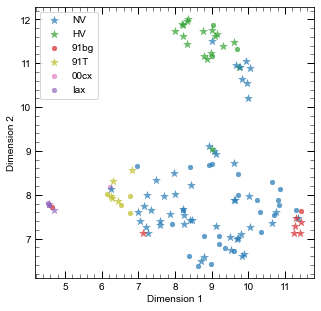

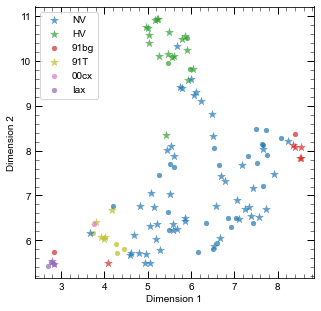

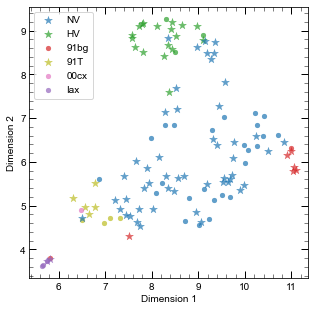

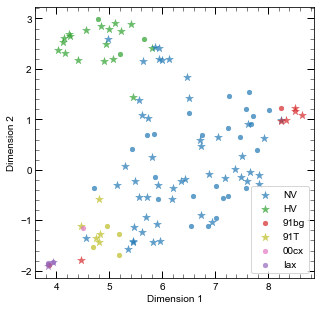

In [25]:
plot_umap(data, 'umap12.pdf', 12)
plot_umap(data, 'umap16.pdf', 16)
plot_umap(data, 'umap20.pdf', 20)
plot_umap(data, 'umap24.pdf', 24, legend_loc='lower right')

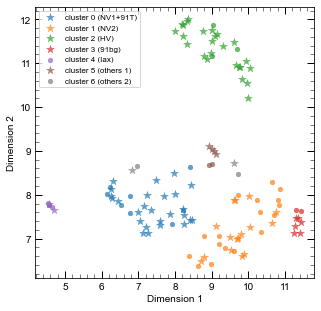

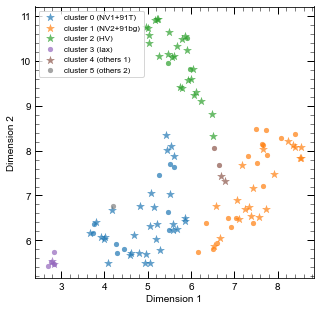

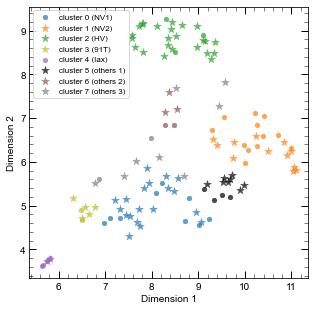

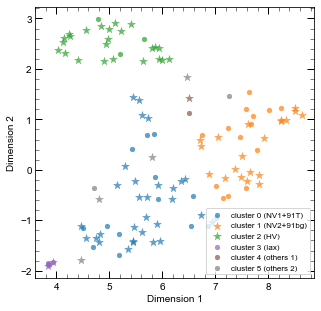

In [26]:
plot_clustering(data, 'clustering_12.pdf', hyper_parameter=12, legend_loc='upper left')
plot_clustering(data, 'clustering_16.pdf', hyper_parameter=16, legend_loc='upper left')
plot_clustering(data, 'clustering_20.pdf', hyper_parameter=20, legend_loc='upper left')
plot_clustering(data, 'clustering_24.pdf', hyper_parameter=24, legend_loc='lower right')

### The mean spectra


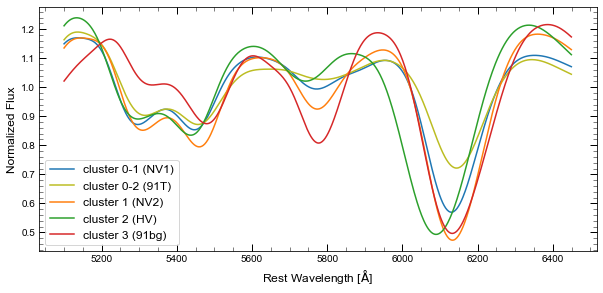

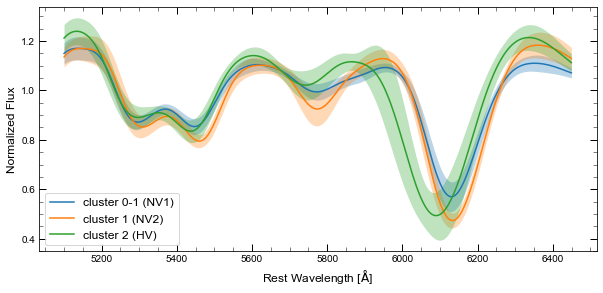

In [27]:
spec_12(groups, fluxes, 'spec.pdf')
spec_12_std(groups, fluxes, 'spec_std.pdf')

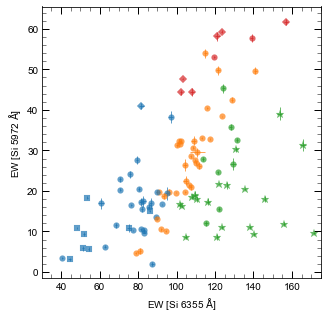

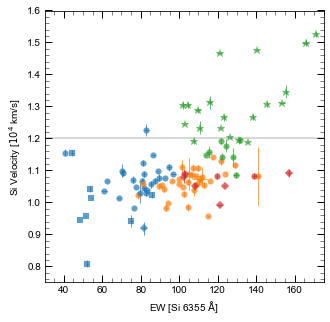

In [28]:
plot_branch_diagram(data, 'branch_diagram_12.pdf')
plot_branch_velocity(data, 'branch_velocity_12.pdf')

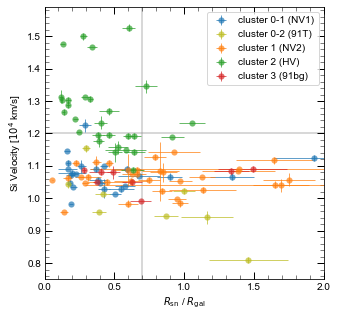

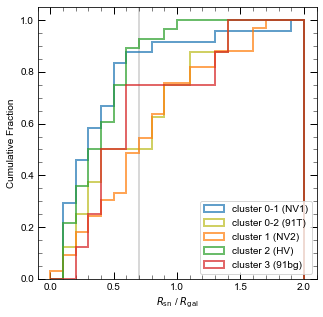

In [29]:
ratio_v_12(groups, 'ratio_v.pdf')
cum_ratio_12(groups, 'cum_ratio.pdf')

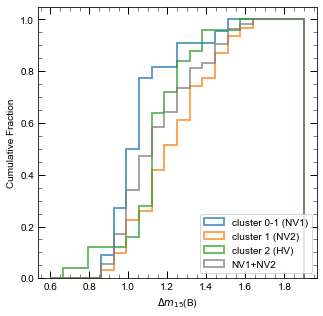

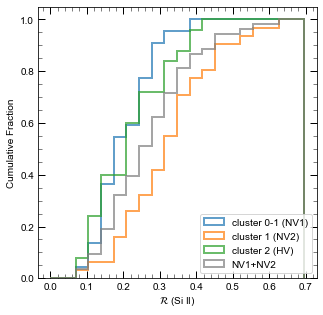

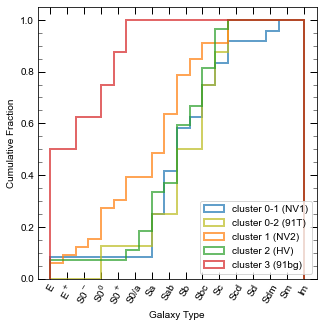

In [30]:
cum_D_12(groups_D15, 'cum_D.pdf')
cum_R_12(groups_D15, 'cum_R.pdf')
cum_t_12(groups, 'cum_t.pdf')